In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
zbest_path = '/global/cfs/cdirs/desi/users/rongpu/spectro/sv1/alltiles_LRGzinfo_mw_trans_added.fits'
tmp = fitsio.read(zbest_path, columns=['TARGETS', 'subset'])
idx = np.where((tmp['subset']=='deep') & (tmp['TARGETS']=='QSO+LRG'))[0]
zbest = Table(fitsio.read(zbest_path, rows=idx))
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

34868
34702


In [4]:
# # Print summary of the tiles
# t = Table()
# t['TILEID'], t['count'] = np.unique(zbest['TILEID'], return_counts=True)
# t['efftime'] = 0
# t['n_exp'] = 0
# for index, tileid in enumerate(t['TILEID']):
#     mask = zbest['TILEID']==tileid
#     t['n_exp'][index] = np.max(zbest['COADD_NUMEXP'][mask])
#     t['efftime'][index] = np.max(zbest['EFFTIME_DARK'][mask])
# t

In [5]:
# Remove FIBERSTATUS!=0 fibers
mask = zbest['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Remove "no data" fibers
mask = zbest['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Require a minimum depth for the deep coadd
min_depth = 3000.
mask = zbest['EFFTIME_DARK']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[mask]

print(len(zbest))

FIBERSTATUS 29372 5496 0.1576230354479752
No data 29370 2 6.809206046574969e-05
Min depth 24255 5115 0.8258426966292135
24255


In [6]:
# Ting-Wen's quality cuts
mask = zbest['DELTACHI2']>20
mask &= zbest['Z']<1.4

mask &= zbest['ZWARN']==0
print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[mask]
print(len(zbest))

Quality cuts 23562 693 0.9714285714285714
23562


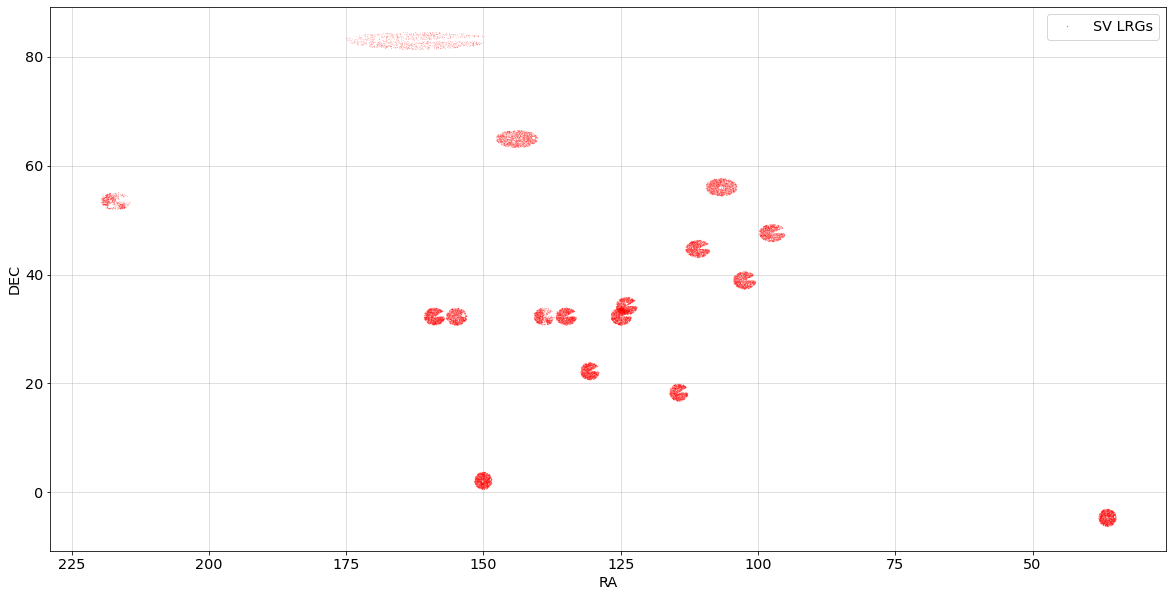

In [7]:
plt.figure(figsize=(20, 10))
plt.plot(zbest['TARGET_RA'], zbest['TARGET_DEC'], 'r.', ms=.1, label='SV LRGs')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right', markerscale=5)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [8]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    zbest['gmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_G']/zbest['MW_TRANSMISSION_G'])
    zbest['rmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_R']/zbest['MW_TRANSMISSION_R'])
    zbest['zmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_Z']/zbest['MW_TRANSMISSION_Z'])
    zbest['w1mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W1']/zbest['MW_TRANSMISSION_W1'])
    zbest['w2mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W2']/zbest['MW_TRANSMISSION_W2'])
    zbest['gfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_G']/zbest['MW_TRANSMISSION_G'])
    zbest['rfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_R']/zbest['MW_TRANSMISSION_R'])
    zbest['zfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_Z']/zbest['MW_TRANSMISSION_Z'])

In [9]:
gmag = zbest['gmag']
rmag = zbest['rmag']
zmag = zbest['zmag']
w1mag = zbest['w1mag']
w2mag = zbest['w2mag']
rfibermag = zbest['rfibermag']
zfibermag = zbest['zfibermag']
gaia_g = zbest['GAIA_PHOT_G_MEAN_MAG']

mask_north = zbest['PHOTSYS']=='N'
mask_south = zbest['PHOTSYS']=='S'

In [10]:
# Changelog:
# - Add GAIA_G>18 cut
# - Revised low-z (g-r vs r-W1) cuts from Jeff (same north and south cuts)
# - Shift the low-z cut intercept by 0.1 in the north (decreasing the density), to account for the north vs south difference
# - Shift the sliding IR cut intercept by 0.05*1.8 (increasing the density), to match the optical target density

# mask_north = cat['PHOTSYS']=='N'
# mask_south = cat['PHOTSYS']=='S'

#################### Updated optical selection ####################

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - zmag > (zmag - 16.83) * 0.45       # sliding optical cut
lrg_mask &= rmag - zmag > (zmag - 13.80) * 0.19       # low-z sliding optical cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_opt_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - zmag > (zmag - 16.79) * 0.45       # sliding optical cut
lrg_mask &= rmag - zmag > (zmag - 13.76) * 0.19       # low-z sliding optical cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_opt_north = lrg_mask.copy()

lrg_opt = lrg_opt_south | lrg_opt_north
print(np.sum(lrg_opt))

#################### Updated IR selection ####################

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - w1mag > (w1mag - 17.27) * 1.8 # sliding IR cut
lrg_mask &= rmag - w1mag > (w1mag - 16.37) * 1.  # low-z sliding IR cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_ir_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - w1mag > (w1mag - 17.23) * 1.8 # sliding IR cut
lrg_mask &= rmag - w1mag > (w1mag - 16.33) * 1.  # low-z sliding IR cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_ir_north = lrg_mask.copy()

lrg_ir = lrg_ir_south | lrg_ir_north
print(np.sum(lrg_ir))

6374
6671


In [11]:
lrg_sv = (zbest['SV1_DESI_TARGET'] & 2**0>0)

# lrg_opt = zbest['SV1_DESI_TARGET'] & 2**3>0
# lrg_ir = zbest['SV1_DESI_TARGET'] & 2**4>0
# print(np.sum(lrg_opt))
# print(np.sum(lrg_ir))
# print(np.sum(lrg_sv))
# print()

ts_qso = (zbest['SV1_DESI_TARGET'] & 2**2>0)
print(np.sum(ts_qso))
print(np.sum(ts_qso & lrg_sv))
print(np.sum(ts_qso & lrg_opt))

559
559
48


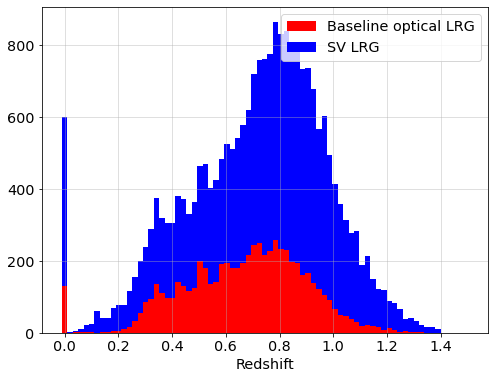

In [12]:
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt], bins=75, range=(-0.01, 1.5), color='red', label='Baseline optical LRG', zorder=1)
plt.hist(zbest['Z'][lrg_sv], bins=75, range=(-0.01, 1.5), color='blue', label='SV LRG', zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.show()

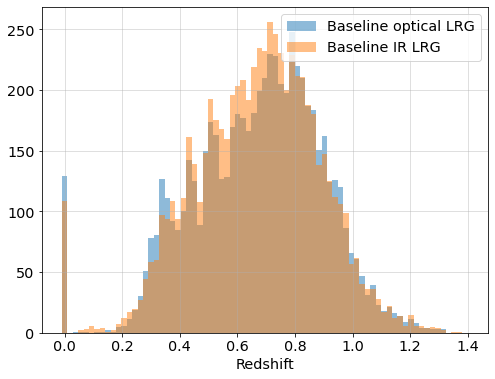

In [13]:
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt], bins=75, range=(-0.01, 1.4), label='Baseline optical LRG', alpha=0.5)
plt.hist(zbest['Z'][lrg_ir], bins=75, range=(-0.01, 1.4), label='Baseline IR LRG', alpha=0.5)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.show()

# Low-z (z<0.3) contamination

In [14]:
mask_star = (zbest['SPECTYPE']=='STAR') | (zbest['Z']<0.0003)

mask_lowz = (zbest['Z']<0.3) & (~mask_star)

mask = lrg_opt.copy()
print('LRG_OPT: {:.1f}%'.format(np.sum(mask & mask_lowz)/np.sum(mask)*100))

mask = lrg_ir.copy()
print('LRG_IR: {:.1f}%'.format(np.sum(mask & mask_lowz)/np.sum(mask)*100))

mask = lrg_sv.copy()
print('LRG_SV: {:.1f}%'.format(np.sum(mask & mask_lowz)/np.sum(mask)*100))

LRG_OPT: 2.7%
LRG_IR: 2.7%
LRG_SV: 4.3%


---------

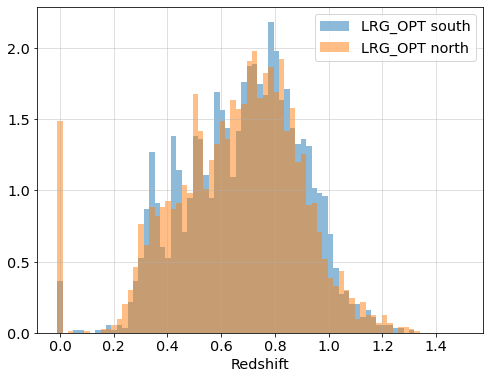

In [15]:
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt_south], bins=75, range=(-0.01, 1.5), label='LRG_OPT south', alpha=0.5, density=True)
plt.hist(zbest['Z'][lrg_opt_north], bins=75, range=(-0.01, 1.5), label='LRG_OPT north', alpha=0.5, density=True)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.show()

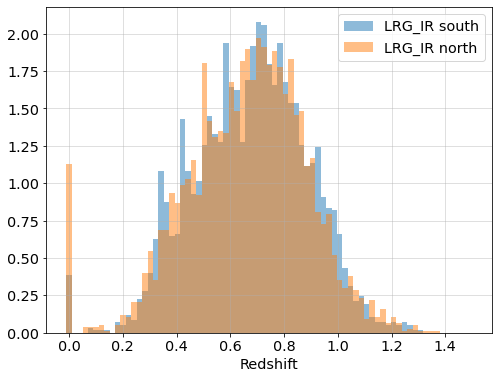

In [16]:
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_ir_south], bins=75, range=(-0.01, 1.5), label='LRG_IR south', alpha=0.5, density=True)
plt.hist(zbest['Z'][lrg_ir_north], bins=75, range=(-0.01, 1.5), label='LRG_IR north', alpha=0.5, density=True)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.show()

In [17]:
from matplotlib.ticker import FormatStrFormatter
sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/global/homes/r/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [18]:
# numbers from another notebook
n_opt_tot = 7047782
n_ir_tot = 7285418
area_tot = 11366.2

area_opt = np.sum(lrg_opt)/n_opt_tot * area_tot
area_ir = np.sum(lrg_ir)/n_ir_tot * area_tot
print(area_opt, area_ir)

10.279568635919784 10.40762797687106


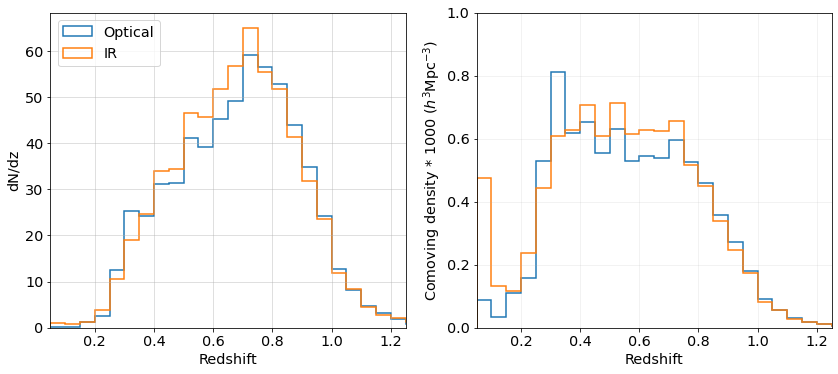

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
bins = np.arange(0.05, 1.45, 0.05)
axes[0].hist(zbest['Z'][lrg_opt], bins=bins, lw=1.5,
             weights=np.ones(int(np.sum(lrg_opt)))/area_opt, histtype='step', label='Optical')
axes[0].hist(zbest['Z'][lrg_ir], bins=bins, lw=1.5,
             weights=np.ones(int(np.sum(lrg_ir)))/area_ir, histtype='step', label='IR')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(0.05, 1.25)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
axes[0].legend(loc='upper left')
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_opt], area=area_opt, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_ir], area=area_ir, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)

--------

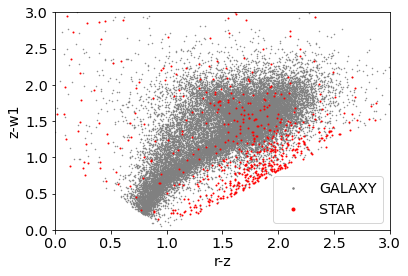

In [20]:
mask_gal = zbest['SPECTYPE']=='GALAXY'
mask_star = (zbest['SPECTYPE']=='STAR') | (zbest['Z']<0.0003)
plt.plot((zbest['rmag']-zbest['zmag'])[mask_gal], (zbest['zmag']-zbest['w1mag'])[mask_gal], '.', color='0.5', ms=1, label='GALAXY')
plt.plot((zbest['rmag']-zbest['zmag'])[mask_star],( zbest['zmag']-zbest['w1mag'])[mask_star], 'r.', ms=2, label='STAR')
plt.xlabel('r-z')
plt.ylabel('z-w1')
plt.axis([0, 3, 0, 3])
plt.legend(markerscale=3)
plt.show()

In [21]:
def color_plot_3x2_simple(cat, color_col, idx=None, title=None, vmin=0.2, vmax=1.0, cmap='Dark2_r', ms=0.3, show=True, figaxis=None, colorbar=True, figsize=(18, 20), grid=False):
    '''
    Replace the g-r vs r-z panel with g-r vs r-W1
    '''
    if idx is None:
        idx = np.arange(len(cat))

    if figaxis is None:
        fig, axes = plt.subplots(3, 2, figsize=figsize)
    else:
        fig, axes = figaxis

    # non-stellar cut
    im = axes[0, 0].scatter((cat['rmag']-cat['zmag'])[idx], (cat['zmag']-cat['w1mag'])[idx], 
                c=cat[color_col][idx], s=ms, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[0, 0].set_xlabel('r - z')
    axes[0, 0].set_ylabel('z - W1')
    axes[0, 0].axis([0.2, 2.8, -1, 3])
    if colorbar:
        fig.colorbar(im, ax=axes[0, 0])
    if grid:
        axes[0, 0].grid(alpha=0.5)

    # g-r vs r-W1
    im = axes[0, 1].scatter((cat['rmag']-cat['w1mag'])[idx], (cat['gmag']-cat['rmag'])[idx], 
             c=cat[color_col][idx], s=ms, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[0, 1].set_xlabel('r - w1')
    axes[0, 1].set_ylabel('g - r')
    axes[0, 1].axis([-0.2, 4.5, 0, 2.7])
    if colorbar:
        fig.colorbar(im, ax=axes[0, 1])
    if grid:
        axes[0, 1].grid(alpha=0.5)

    # optical sliding cut
    im = axes[1, 0].scatter((cat['zmag'])[idx], (cat['rmag']-cat['zmag'])[idx], 
             c=cat[color_col][idx], s=ms, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[1, 0].set_xlabel('z')
    axes[1, 0].set_ylabel('r - z')
    axes[1, 0].axis([17, 22., 0.5, 2.6])
    if colorbar:
        fig.colorbar(im, ax=axes[1, 0])
    if grid:
        axes[1, 0].grid(alpha=0.5)
    x = np.linspace(17, 22)

    # IR sliding cut
    im = axes[1, 1].scatter((cat['w1mag'])[idx], (cat['rmag']-cat['w1mag'])[idx], 
             c=cat[color_col][idx], s=ms, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[1, 1].set_xlabel('W1')
    axes[1, 1].set_ylabel('r - W1')
    axes[1, 1].axis([16.3, 20.2, 0.3, 5.])
    if colorbar:
        fig.colorbar(im, ax=axes[1, 1])
    if grid:
        axes[1, 1].grid(alpha=0.5)
    
    # zfiber vs z
    im = axes[2, 0].scatter((cat['zmag'])[idx], (cat['zfibermag'])[idx], 
             c=cat[color_col][idx], s=ms, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[2, 0].set_xlabel('z')
    axes[2, 0].set_ylabel('zfiber')
    axes[2, 0].axis([17, 22., 18, 23.])
    if colorbar:
        fig.colorbar(im, ax=axes[2, 0])
    if grid:
        axes[2, 0].grid(alpha=0.5)

    axes[2, 1].axis('off')

    if title is not None:
        fig.suptitle(title)
    fig.subplots_adjust(top=0.96)
    
    if show:
        plt.show()
    else:
        return fig, axes

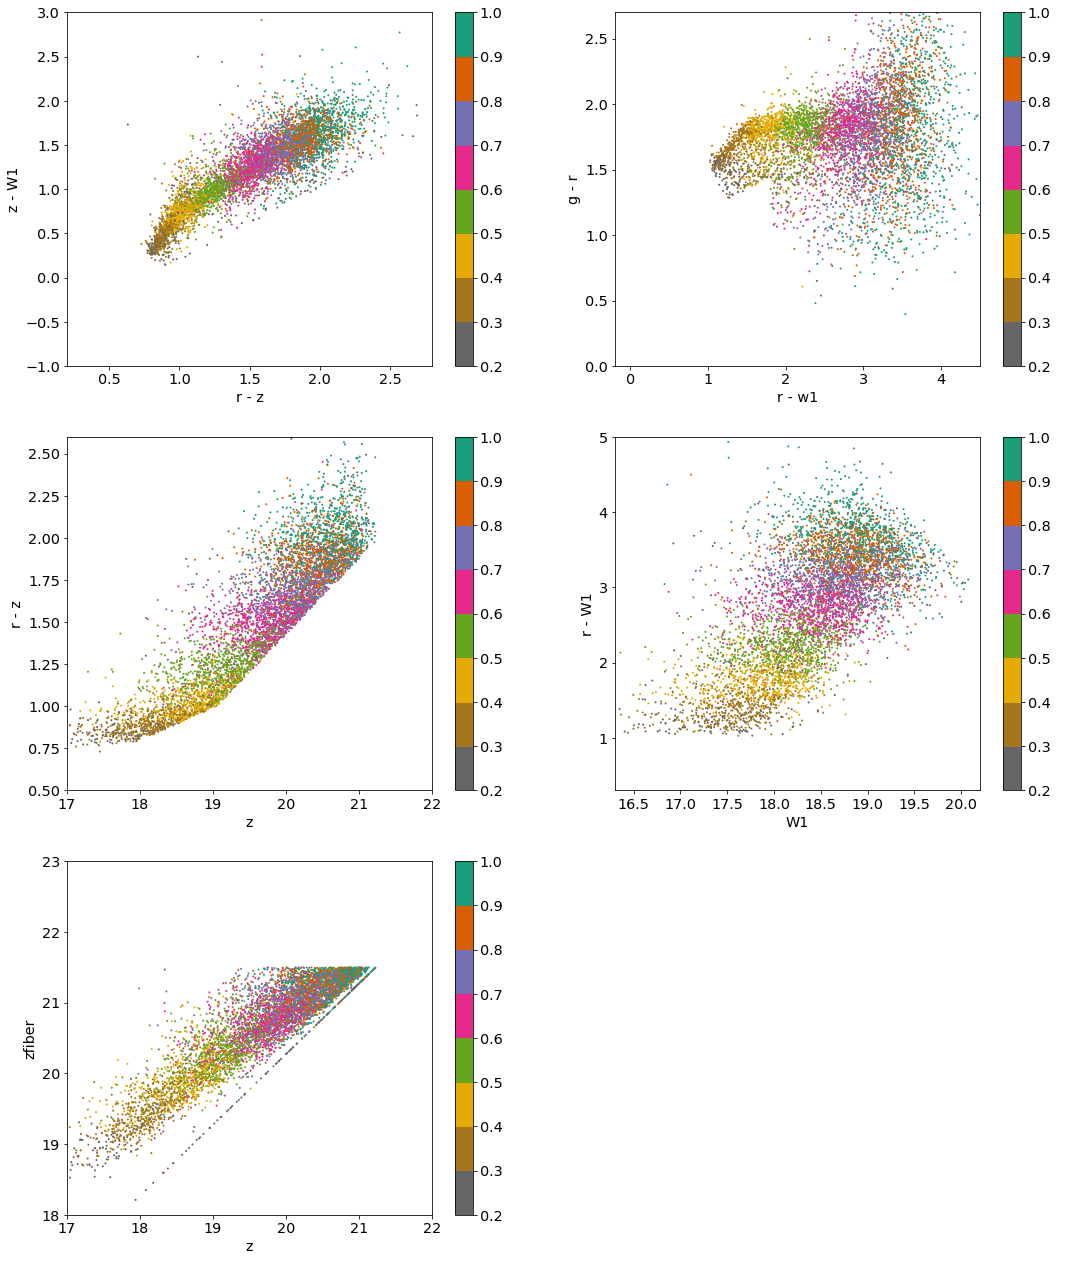

In [22]:
color_plot_3x2_simple(zbest[lrg_opt], color_col='Z', ms=1)

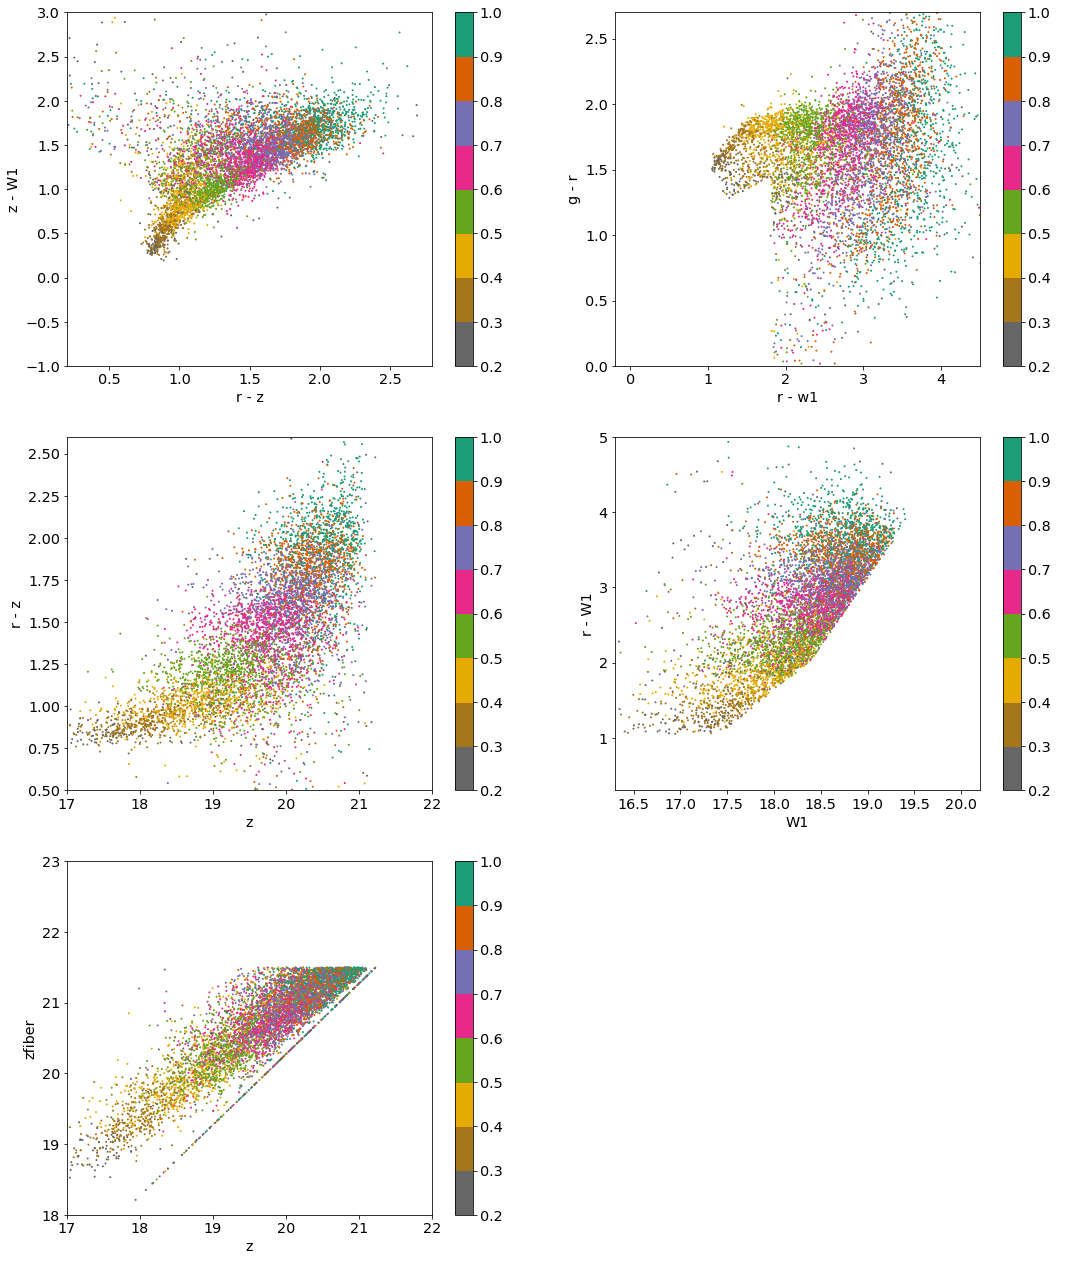

In [23]:
color_plot_3x2_simple(zbest[lrg_ir], color_col='Z', ms=1)